## **EE5841 Final Project**

Members: Jackson Newell, Jayden Cozort, Reid Beckes, Md Istiak Ahammed

##### **Current Notes:**
Using the MNIST dataset to test the ResNet implementation

Using population data for Apidae (Family of bees including honey bees, bumble bees, etc.)
- Whole world dataset is +8,000,000 occurances. Too big for testing. Going to use just the US which is +2,000,000, may be more managable.
Changes currently to make:
- Import SDM (Occurance) data from GBIF (Jackson currently has the Apidae occurance dataset downloaded)
- Create dataset to train and test with
  - Get Lat a Long for the input
  - Create corresponding matrix of ouputs [0, 1]

##### **Sources:**

GBIF.org (22 March 2026) GBIF Occurrence Download  https://doi.org/10.15468/dl.ggr73u

[GeeksforGeeks ResNet Implementation, used code from here for project](https://www.geeksforgeeks.org/deep-learning/residual-networks-resnet-deep-learning/)

[GeeksforGeeks UNet Implementation, used code from here for the project](https://www.geeksforgeeks.org/machine-learning/u-net-architecture-explained/)

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, BatchNormalization, Activation, Conv2D, Convolution2DTranspose
from tensorflow.keras.layers import AveragePooling2D, Input, Flatten, Add, MaxPool2D, Resizing, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Model
import numpy as np
import pandas as pd
from keras.datasets import mnist
from google.colab import files
from pygbif import species
from pygbif import occurrences as occ
import matplotlib.pyplot as plt
import random

device_name = tf.test.gpu_device_name()
if not device_name:
    raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))

print("TensorFlow:", tf.__version__)

Found GPU at: /device:GPU:0
TensorFlow: 2.19.0


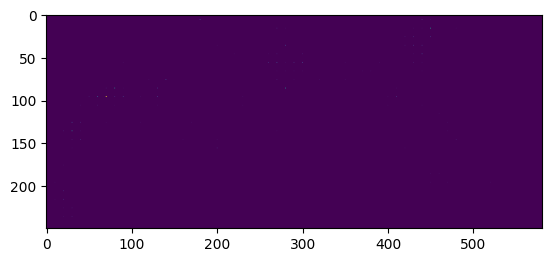

In [ ]:
batch_size = 100
epochs = 20
num_class = 10
depth = 152

# (x_train, y_train), (x_test, y_test) = mnist.load_data()

key = 4334
M = np.zeros((250, 581))
latlong_box = "POLYGON((-125 24.5,-66.9 24.5,-66.9 49.5,-125 49.5,-125 24.5))"

data = occ.search(taxonKey=key, hasCoordinate=True, geometry=latlong_box, limit=300)

for i in range(len(data['results'])):
  x = int((round(data['results'][i]['decimalLatitude']) - 24.4) * 10)
  y = int((round(data['results'][i]['decimalLongitude']) + 125) * 10)
  M[x, y] += 1

plt.imshow(M)
plt.show()

# x_train = x_train.astype('float32') / 255
# x_test = x_test.astype('float32') / 255

# x_train = x_train.reshape(x_train.shape[0], x_train.shape[1], x_train.shape[2], 1)
# x_test = x_test.reshape(x_test.shape[0], x_test.shape[1], x_test.shape[2], 1)

# input_shape = x_train.shape[1:]

# print(input_shape)

# y_train = keras.utils.to_categorical(y_train, num_class)
# y_test = keras.utils.to_categorical(y_test, num_class)

In [ ]:
def resnet_layer(inputs,
                 num_filters=16,
                 kernel_size=3,
                 strides=1,
                 activation='relu',
                 conv_first=True):

  conv = Conv2D(num_filters,
                  kernel_size=kernel_size,
                  strides=strides,
                  padding='same',
                  kernel_initializer='he_normal',
                  kernel_regularizer=l2(1e-4))


  x = inputs
  if conv_first:
      x = conv(x)
      if activation is not None:
          x = Activation(activation)(x)
  else:
      if activation is not None:
          x = Activation(activation)(x)
      x = conv(x)
  return x

def resnet_model(input_shape, depth = 50, num_classes = 10, num_filters = 16):
  num_res_blocks = int((depth - 2) / 6)
  inputs = Input(shape=input_shape)
  x = resnet_layer(inputs=inputs)

  for stack in range(3):
    for res_block in range(num_res_blocks):
        strides = 1
        if stack > 0 and res_block == 0:
            strides = 2
        y = resnet_layer(x, num_filters=num_filters, strides=strides)
        y = resnet_layer(y, num_filters=num_filters, activation=None)
        if stack > 0 and res_block == 0:
            x = resnet_layer(x, num_filters=num_filters, kernel_size=1,
                             strides=strides, activation=None, batch_normalization=False)
        x = Add()([x, y])
        x = Activation('relu')(x)
    num_filters *= 2

    x = AveragePooling2D(pool_size=8)(x)
    y = Flatten()(x)
    outputs = Dense(num_classes, activation='softmax', kernel_initializer='he_normal')(y)
    model = Model(inputs=inputs, outputs=outputs)
    return model

In [ ]:
model = resnet_model(input_shape=input_shape, depth=depth, num_classes=num_class)

model.compile(loss='categorical_crossentropy',
              optimizer=Adam(learning_rate=1e-5),
              metrics=['accuracy'])
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_76 (Conv2D)  │ (None, 28, 28,    │        160 │ input_layer_8[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_72       │ (None, 28, 28,    │          0 │ conv2d_76[0][0]   │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_77 (Conv2D)  │ (None, 28, 28,    │      2,320 │ activation_72[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_73       │ (None, 28, 28,    │          0 │ conv2d_77[0][0]   │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_78 (Conv2D)  │ (None, 28, 28,    │      2,320 │ activation_73[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_33 (Add)        │ (None, 28, 28,    │          0 │ activation_72[0]… │
│                     │ 16)               │            │ conv2d_78[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_74       │ (None, 28, 28,    │          0 │ add_33[0][0]      │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_79 (Conv2D)  │ (None, 28, 28,    │      2,320 │ activation_74[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_75       │ (None, 28, 28,    │          0 │ conv2d_79[0][0]   │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_80 (Conv2D)  │ (None, 28, 28,    │      2,320 │ activation_75[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_34 (Add)        │ (None, 28, 28,    │          0 │ activation_74[0]… │
│                     │ 16)               │            │ conv2d_80[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_76       │ (None, 28, 28,    │          0 │ add_34[0][0]      │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_81 (Conv2D)  │ (None, 28, 28,    │      2,320 │ activation_76[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_77       │ (None, 28, 28,    │          0 │ conv2d_81[0][0]   │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_82 (Conv2D)  │ (None, 28, 28,    │      2,320 │ activation_77[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_35 (Add)        │ (None, 28, 28,    │          0 │ activation_76[0]

 Total params: 117,610 (459.41 KB)

 Trainable params: 117,610 (459.41 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
hist = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, verbose=True)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.3511 - loss: 4.0227
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.5160 - loss: 1.9714
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.6650 - loss: 1.2885
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.7662 - loss: 0.9382
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.8336 - loss: 0.7215
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.8706 - loss: 0.5949
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.8973 - loss: 0.5066
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.9158 - loss: 0.4442
Epoch 9/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.9280 - loss: 0.4030
Epoch 10/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.9370 - loss: 0.3725
Epoch 11/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.9445 - loss: 0.3479
Epoch 12

In [ ]:
test = model.evaluate(x_test, y_test, batch_size=batch_size, verbose=True)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9656 - loss: 0.2790
[0.2790128290653229, 0.9656000137329102]


### U NET MODEL

In [ ]:
def encoder(input, num_filters):
  x = Conv2D(num_filters, 3, padding='valid')(input)
  x = Activation('relu')(x)

  x = Conv2D(num_filters, 3, padding='valid')(x)
  x = Activation('relu')(x)

  x = MaxPool2D(pool_size=(2,2), strides=2)(x)

  return x

def decoder(input, skip, num_filters):
  x = Convolution2DTranspose(num_filters, (2,2), strides=2, padding='valid')(input)

  skip = Resizing(x.shape[1], x.shape[2])(skip)
  x = Concatenate()([x, skip])
  x = Conv2D(num_filters, 3, padding='valid')(x)
  x = Activation('relu')(x)
  x = Conv2D(num_filters, 3, padding='valid')(x)
  x = Activation('relu')(x)

  return x

def unet_model(input_shape=(28, 28, 1), num_classes=1):
  inputs = Input(shape=input_shape, name='image')

  encoder_block1 = encoder(inputs, 64)
  encoder_block2 = encoder(encoder_block1, 128)
  encoder_block3 = encoder(encoder_block2, 256)
  encoder_block4 = encoder(encoder_block3, 512)

  bottleneck = Conv2D(1024, 3, padding='valid')(encoder_block4)
  bottleneck = Activation('relu')(bottleneck)
  bottleneck = Conv2D(1024, 3, padding='valid')(bottleneck)
  bottleneck = Activation('relu')(bottleneck)

  decoder_block1 = decoder(bottleneck, encoder_block4, 512)
  decoder_block2 = decoder(decoder_block1, encoder_block3, 256)
  decoder_block3 = decoder(decoder_block2, encoder_block2, 128)
  decoder_block4 = decoder(decoder_block3, encoder_block1, 64)

  outputs = Conv2D(num_classes, 1, padding='valid', activation='sigmoid')(decoder_block4)

  model = Model(inputs=inputs, outputs=outputs, name='UNET')
  return model

In [ ]:
import tensorflow_datasets as tfds


model2 = unet_model(input_shape=(572, 572, 3), num_classes=2)
model2.summary()

Model: "UNET"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 572, 572,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_304 (Conv2D) │ (None, 570, 570,  │      1,792 │ image[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_288      │ (None, 570, 570,  │          0 │ conv2d_304[0][0]  │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_305 (Conv2D) │ (None, 568, 568,  │     36,928 │ activation_288[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_289      │ (None, 568, 568,  │          0 │ conv2d_305[0][0]  │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_64    │ (None, 284, 284,  │          0 │ activation_289[0… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_306 (Conv2D) │ (None, 282, 282,  │     73,856 │ max_pooling2d_64… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_290      │ (None, 282, 282,  │          0 │ conv2d_306[0][0]  │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_307 (Conv2D) │ (None, 280, 280,  │    147,584 │ activation_290[0… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_291      │ (None, 280, 280,  │          0 │ conv2d_307[0][0]  │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_65    │ (None, 140, 140,  │          0 │ activation_291[0… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_308 (Conv2D) │ (None, 138, 138,  │    295,168 │ max_pooling2d_65… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_292      │ (None, 138, 138,  │          0 │ conv2d_308[0][0]  │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_309 (Conv2D) │ (None, 136, 136,  │    590,080 │ activation_292[0… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_293      │ (None, 136, 136,  │          0 │ conv2d_309[0][0]  │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_66    │ (None, 68, 68,    │          0 │ activation_293[0… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_310 (Conv2D) │ (None, 66, 66,    │  1,180,160 │ max_pooling2d_66

 Total params: 31,031,810 (118.38 MB)

 Trainable params: 31,031,810 (118.38 MB)

 Non-trainable params: 0 (0.00 B)